# Image analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

import mnist_graph as mg
from mnist_graph import GRID, N_PIX, T_LIST, ANCHOR_ROW, ANCHOR_COL

# the per-pixel standardized retrain, with the Hessian computed at x0=128
STD_PATTERN = "hessian_mnist_*_std128.pickle"
TITLE = "Standardized input"

H, path = mg.load_hessian(pattern=STD_PATTERN)
print(f"[std] {path.split('/')[-1]}")

img28 = mg.load_reference_image()
print(f"timesteps: t={T_LIST[0]}..{T_LIST[-1]} (count={len(T_LIST)})")

records = mg.anchor_trajectories(H)
cluster = mg.global_clustering(H)
graph = mg.selected_graph(cluster)

print(f"[std] global pairs: {cluster['iu'].size:,}, "
      f"selected edges: {graph['sel'].size:,}")

[std] hessian_mnist_mnist_unet_ddpm_epoch50_x0_128_bx0_8_S_5000_std128.pickle
timesteps: t=1..30 (count=30)


/home/js/.conda/envs/fid/lib/python3.8/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


[std] global pairs: 306,936, selected edges: 685


In [2]:
# Bucket spec for the L1-distance views (identical to image_results.ipynb).
BUCKETS = {
    "d1":   {"color": "#08306b", "lw": 1.6, "alpha": 0.95, "z": 3,
             "label": r"$\ell^{1}$-distance $= 1$"},
    "d2":   {"color": "#4292c6", "lw": 1.6, "alpha": 0.95, "z": 2,
             "label": r"$\ell^{1}$-distance $= 2$"},
    "dge3": {"color": "#a50f15", "lw": 1.0, "alpha": 0.30, "z": 0,
             "label": r"$\ell^{1}$-distance $\geq 3$"},
}
BUCKET_ORDER = ["dge3", "d2", "d1"]   # draw order: back -> front


def bucket_of(d):
    if d == 1:
        return "d1"
    if d == 2:
        return "d2"
    return "dge3"


# Shared constants for the estimated-graph figure (as in image_results.ipynb).
SHORT_COLORS = {1: "black", 2: "black", 3: "#7570b3", 4: "#e7298a"}
XLIM = (-0.5, GRID - 0.5)
YLIM = (GRID - 0.5, -0.5)   # row 0 at top, like imshow


## MNIST image and $\widetilde H_{ij}(t)$ at anchor $(i,j) = (15,16)$

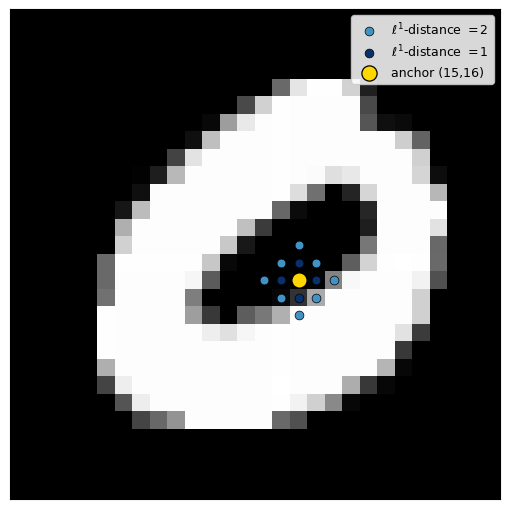

In [3]:
# Anchor neighbourhood on the reference digit.
rr, cc = np.mgrid[0:GRID, 0:GRID]
l1 = np.abs(rr - ANCHOR_ROW) + np.abs(cc - ANCHOR_COL)
d1_r, d1_c = np.where(l1 == 1)
d2_r, d2_c = np.where(l1 == 2)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(img28, cmap="gray", interpolation="nearest")
ax.scatter(d2_c, d2_r, c=BUCKETS["d2"]["color"], s=40,
           edgecolors="black", linewidths=0.5, zorder=3, label=BUCKETS["d2"]["label"])
ax.scatter(d1_c, d1_r, c=BUCKETS["d1"]["color"], s=40,
           edgecolors="black", linewidths=0.5, zorder=4, label=BUCKETS["d1"]["label"])
ax.scatter([ANCHOR_COL], [ANCHOR_ROW], c="gold", s=120,
           edgecolors="black", linewidths=0.9, zorder=5,
           label=f"anchor ({ANCHOR_ROW},{ANCHOR_COL})")
ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

saved ../figures/mnist_hessian_anchor_std.{pdf,png}


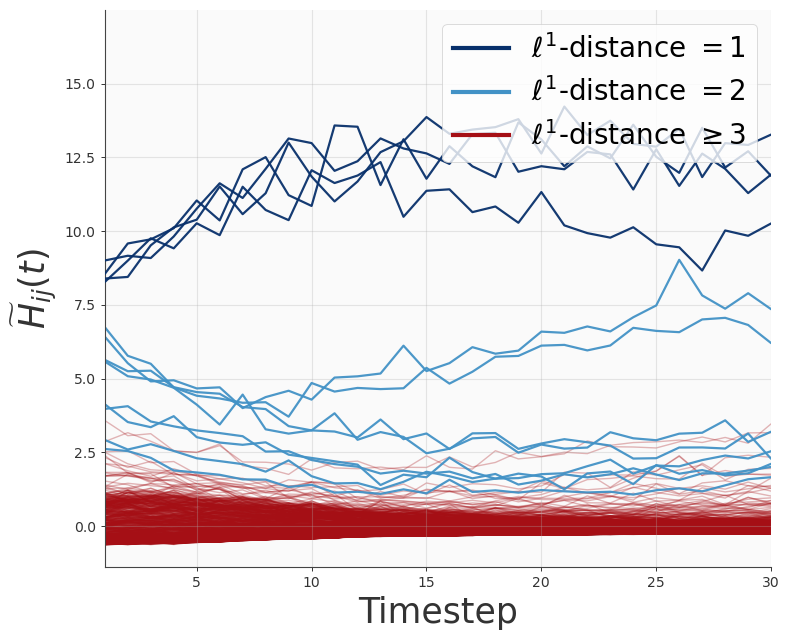

In [4]:
# In the exact geometry of image_results.ipynb.

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.set_facecolor("#fafafa")

# Draw bucket-by-bucket so the background bucket stays under the foreground ones
for b in BUCKET_ORDER:
    spec = BUCKETS[b]
    for rec in records:
        if bucket_of(rec["l1"]) != b:
            continue
        ax.plot(T_LIST, rec["vals_std"], color=spec["color"], linewidth=spec["lw"],
                alpha=spec["alpha"], zorder=spec["z"], solid_capstyle="round")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#444"); ax.spines[spine].set_linewidth(0.8)
ax.tick_params(axis="both", length=3, width=0.7, colors="#333", labelsize=10)
ax.set_axisbelow(True)
ax.set_xlabel("Timestep", fontsize=25, color="#333")
ax.set_ylabel(r"$\widetilde H_{ij}(t)$", fontsize=25, color="#333")

all_vals = np.asarray([rec["vals_std"] for rec in records])
y_lo, y_hi = all_vals.min(), all_vals.max()
pad = 0.05 * (y_hi - y_lo)
# extra headroom at the top so the legend does not sit on the L1=1 curves
ax.set_ylim(y_lo - pad, y_hi + 0.22 * (y_hi - y_lo))
ax.set_xlim(min(T_LIST), max(T_LIST))

legend_handles = [Line2D([0], [0], color=BUCKETS[b]["color"], lw=3, label=BUCKETS[b]["label"])
                  for b in ("d1", "d2", "dge3")]
leg = ax.legend(handles=legend_handles, loc="upper right", fontsize=20,
                frameon=True, framealpha=0.8, edgecolor="#cccccc")
leg.get_frame().set_linewidth(0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig("../figures/mnist_hessian_anchor_std.pdf", bbox_inches="tight")
fig.savefig("../figures/mnist_hessian_anchor_std.png", dpi=300, bbox_inches="tight")
print("saved ../figures/mnist_hessian_anchor_std.{pdf,png}")
plt.show()


## Estimated graph


Short-range edges (L1<=4) among selected: 685
saved ../figures/mnist_graph_std.{pdf,png}


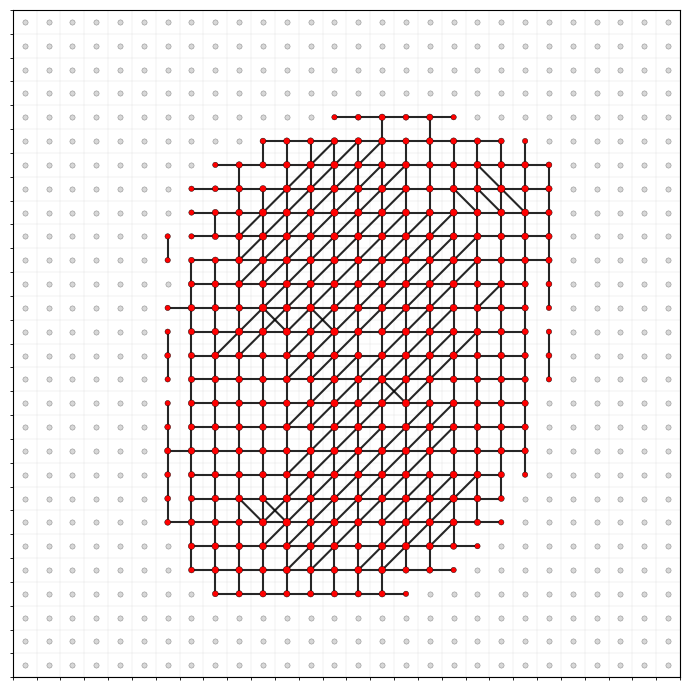

In [5]:
# In the exact geometry of image_results.ipynb.
segments = graph["segments"]
edge_l1 = graph["edge_l1"]

short_mask = edge_l1 <= 4
print(f"Short-range edges (L1<=4) among selected: {int(short_mask.sum()):,}")

# L1 in {1,2} share black; L1 = 3, 4 keep distinct colors
seg_colors = np.array([SHORT_COLORS[d] for d in edge_l1[short_mask]])

deg_s_grid = mg.degree_grid_for_mask(cluster, graph, short_mask)
conn_r, conn_c = np.where(deg_s_grid > 0)
unconn_r, unconn_c = np.where(deg_s_grid == 0)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor("white")
ax.set_xticks(np.arange(-0.5, GRID, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID, 1), minor=True)
ax.grid(which="minor", color="lightgray", linewidth=0.3, alpha=0.7)

ax.add_collection(LineCollection(segments[short_mask], colors=seg_colors,
                                 linewidths=1.5, alpha=0.85))
ax.scatter(unconn_c, unconn_r, s=14, c="lightgray", edgecolors="dimgray",
           linewidths=0.3, alpha=0.9, zorder=2)
ax.scatter(conn_c, conn_r, s=12 + 3.0 * deg_s_grid[conn_r, conn_c], c="red",
           edgecolors="black", linewidths=0.3, zorder=3)

ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

fig.savefig("../figures/mnist_graph_std.pdf", bbox_inches="tight")
fig.savefig("../figures/mnist_graph_std.png", dpi=300, bbox_inches="tight")
print("saved ../figures/mnist_graph_std.{pdf,png}")
plt.show()


## Real samples and generated samples, without standardization and with standardization

real: (35, 28, 28), generated raw: (35, 28, 28), std: (35, 28, 28)


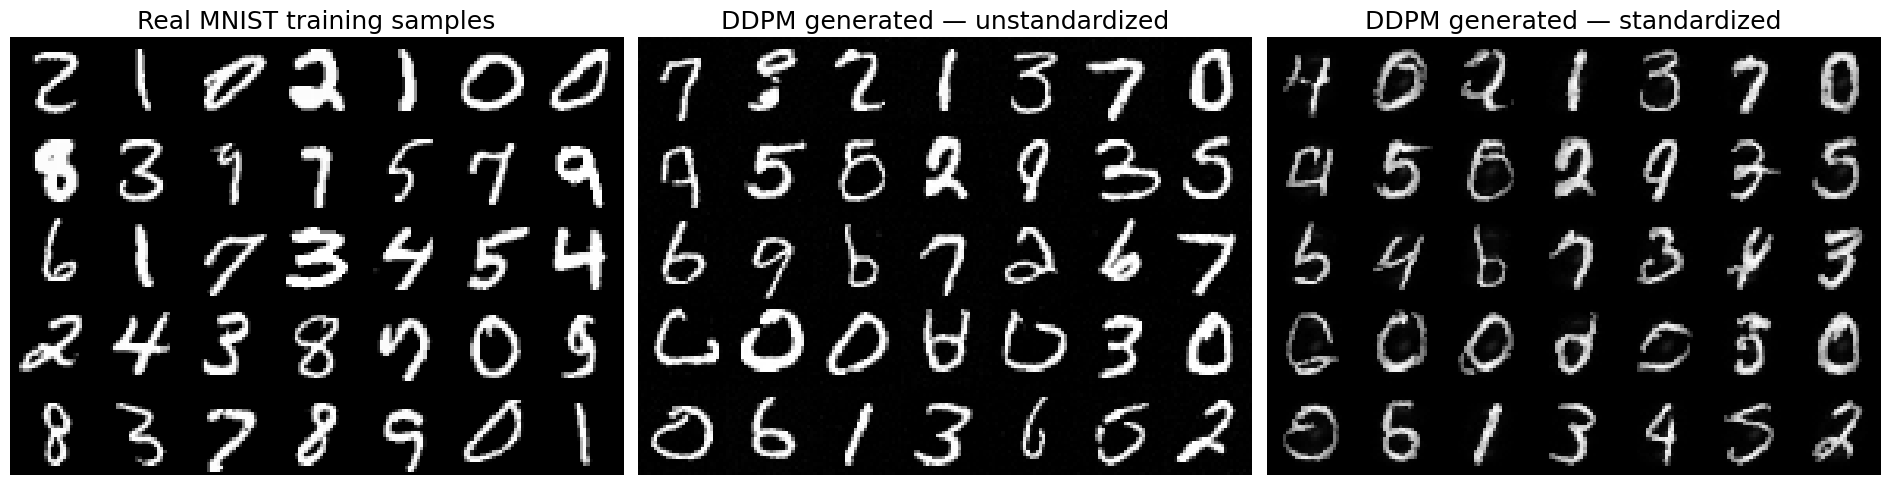

In [6]:
import math

real_imgs = np.load(mg.DATA_DIR + "/mnist_real_samples.npy")     # (N, 28, 28) in [0,1]
gen_raw = np.load(mg.DATA_DIR + "/rev_mnist_gen_raw.npy")
gen_std = np.load(mg.DATA_DIR + "/rev_mnist_gen_std.npy")
print(f"real: {real_imgs.shape}, generated raw: {gen_raw.shape}, std: {gen_std.shape}")


def make_grid(imgs, nrow):
    """Tile (N, 28, 28) images into a single (nrow*28, ncol*28) array."""
    n, h, w = imgs.shape
    ncol = math.ceil(n / nrow)
    grid = np.ones((nrow * h, ncol * w), dtype=np.float32)
    for k in range(n):
        r, c = divmod(k, ncol)
        grid[r * h:(r + 1) * h, c * w:(c + 1) * w] = imgs[k]
    return grid


nrow = int(math.sqrt(real_imgs.shape[0]))
panels = [("Real MNIST training samples", real_imgs),
          ("DDPM generated — unstandardized", gen_raw),
          ("DDPM generated — standardized", gen_std)]

fig, axes = plt.subplots(1, 3, figsize=(19, 6.6))
for ax, (title, imgs) in zip(axes, panels):
    ax.imshow(make_grid(imgs, nrow), cmap="gray", interpolation="nearest")
    ax.set_title(title, fontsize=18)
    ax.axis("off")
plt.tight_layout(); plt.show()